# Assess Basyescan results
This checks for model convergence, identifies putative outliers, and plots results.

In [2]:
library(coda)
library(adegenet)

In [6]:
plot_bayescan <- function(res, FDR = 0.05, size = 1, pos = 0.35, highlight = NULL, name_highlighted = F, add_text = T) {
  if (is.character(res)) {
    res <- read.table(res)
  }

  colfstat <- 5
  colq <- colfstat - 2

  highlight_rows <- which(is.element(as.numeric(row.names(res)), highlight))
  non_highlight_rows <- setdiff(1:nrow(res), highlight_rows)

  outliers <- as.integer(row.names(res[res[, colq] <= FDR, ]))

  ok_outliers <- TRUE
  if (sum(res[, colq] <= FDR) == 0) {
    ok_outliers <- FALSE
  }

  res[res[, colq] <= 0.0001, colq] <- 0.0001

  # plot
  plot(
    log10(res[, colq]),
    res[, colfstat],
    xlim = rev(range(log10(res[, colq]))),
    xlab = "log10(q value)",
    ylab = names(res[colfstat]),
    type = "n"
)
  points(
    log10(res[non_highlight_rows, colq]),
    res[non_highlight_rows, colfstat],
    pch = 19,
    cex = size
)

  if (name_highlighted) {
    if (length(highlight_rows) > 0) {
        text(
            log10(res[highlight_rows, colq]),
            res[highlight_rows,
            colfstat],
            row.names(res[highlight_rows, ]),
            col = "indianred",
            cex = size * 1.2,
            font = 2
        )
    }
  } else {
    points(
        log10(res[highlight_rows, colq]),
        res[highlight_rows, colfstat],
        col = "indianred",
        pch = 19,
        cex = size
    )
    # add names of loci over p and vertical line
    if (ok_outliers & add_text) {
        text(
          log10(res[res[, colq] <= FDR, ][, colq]) + pos * (round(runif(nrow(res[res[, colq] <= FDR, ]), 1, 2)) * 2 - 3), res[res[, colq] <= FDR, ][, colfstat], row.names(res[res[, colq] <= FDR, ]),
          cex = size
        )
    }
  }
  lines(c(log10(FDR), log10(FDR)), c(-1, 1), lwd = 2)

  return(list("outliers" = outliers, "nb_outliers" = length(outliers)))
}


In [ ]:
infile <- "yft_bscan_fst.txt"
yft_bscan_fst <- read.csv(infile, sep="")
genfile <- "../../data/YFT.snp.kinrm.pcrelate.gen"
head(yft_bscan_fst)


,prob,log10.PO.,qval,alpha,fst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.00986732,-2.00149,0.983467,-0.0020595,0.0052697
2,0.00906730,-2.03860,0.986080,-0.0013006,0.0052752
3,0.01053400,-1.97280,0.978870,-0.0066249,0.0052511
4,0.01060100,-1.97000,0.978200,-0.0046491,0.0052553
5,0.01713400,-1.75860,0.931590,0.0148210,0.0054554
6,0.02040100,-1.68140,0.911030,0.0210730,0.0055476


## convergence checks

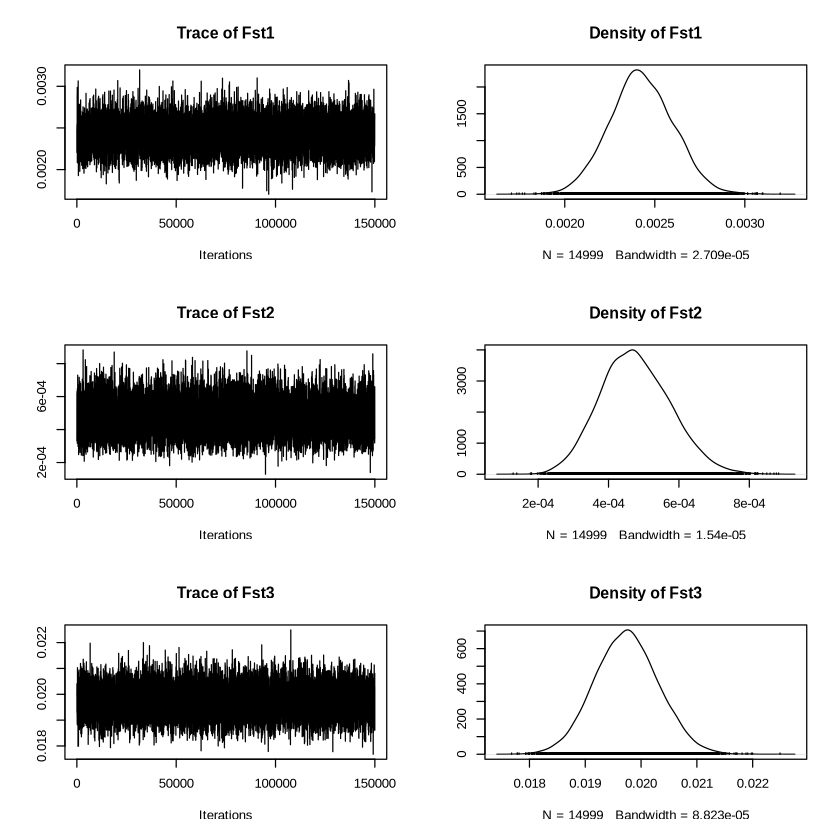

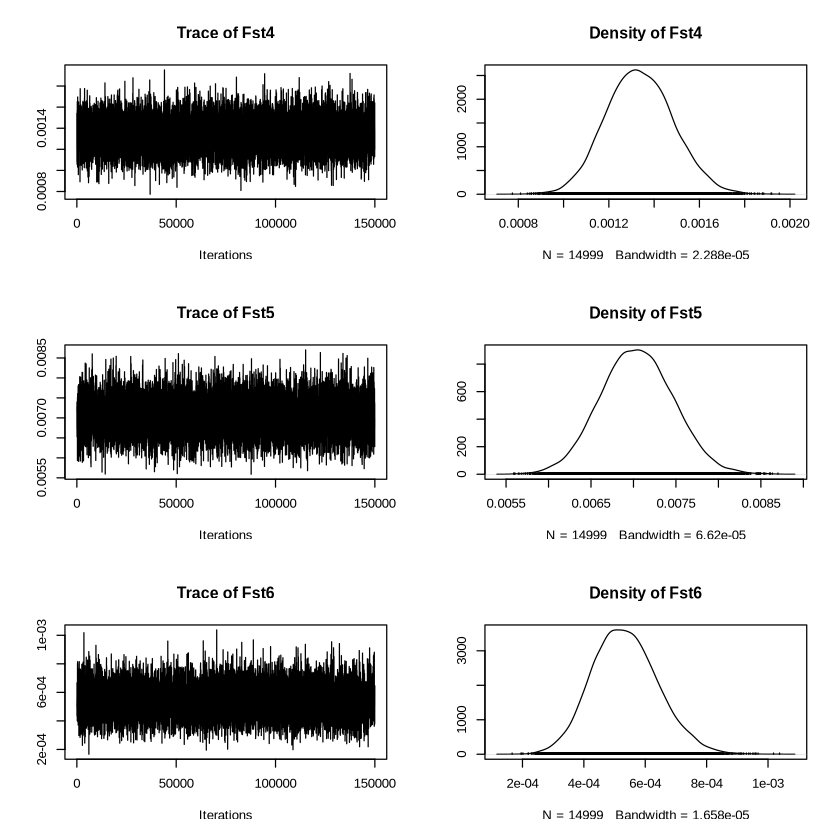

In [8]:
chain <- read.table("yft_bscan.sel", header = TRUE)
chain <- chain[-c(1)]
mc_chain <- mcmc(chain, thin = 10)
plot(mc_chain)


In [9]:
summary(mc_chain)



Iterations = 1:149981
Thinning interval = 10 
Number of chains = 1 
Sample size per chain = 14999 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

          Mean        SD  Naive SE Time-series SE
Fst1 0.0024255 1.758e-04 1.435e-06      1.868e-06
Fst2 0.0004767 9.938e-05 8.115e-07      9.680e-07
Fst3 0.0197417 5.695e-04 4.650e-06      5.367e-06
Fst4 0.0013366 1.477e-04 1.206e-06      1.575e-06
Fst5 0.0070421 4.273e-04 3.489e-06      3.924e-06
Fst6 0.0005348 1.070e-04 8.737e-07      1.082e-06

2. Quantiles for each variable:

          2.5%       25%       50%       75%     97.5%
Fst1 0.0020853 0.0023083 0.0024210 0.0025427 0.0027713
Fst2 0.0002941 0.0004070 0.0004719 0.0005425 0.0006812
Fst3 0.0186408 0.0193560 0.0197374 0.0201196 0.0208724
Fst4 0.0010572 0.0012343 0.0013326 0.0014352 0.0016329
Fst5 0.0062228 0.0067500 0.0070384 0.0073284 0.0078929
Fst6 0.0003363 0.0004601 0.0005300 0.0006042 0.0007566


In [10]:
autocorr.diag(mc_chain)

,Fst1,Fst2,Fst3,Fst4,Fst5,Fst6
Lag 0,1.000000000,1.000000000,1.000000000,1.000000e+00,1.000000000,1.000000000
Lag 10,0.257554533,0.174501159,0.118711654,2.215358e-01,0.076790158,0.192507466
Lag 50,-0.002521242,0.000878128,0.013546081,7.423139e-03,-0.006146108,-0.001656545
Lag 100,0.004368677,0.003713045,-0.012247827,-8.730389e-06,0.003754452,0.008860188
Lag 500,-0.005266885,-0.012031758,0.002837044,-1.001635e-02,0.003427726,0.002834501


In [11]:
effectiveSize(mc_chain)


Fst1      Fst2      Fst3      Fst4      Fst5      Fst6 
 8854.643 10541.353 11261.177  8796.633 11859.677  9784.197

In [12]:
geweke.diag(mc_chain, frac1 = 0.1, frac2 = 0.5)



Fraction in 1st window = 0.1
Fraction in 2nd window = 0.5 

   Fst1    Fst2    Fst3    Fst4    Fst5    Fst6 
-0.4449 -0.9200 -0.2338 -0.5163  0.9931  0.5668 


In [13]:
heidel.diag(mc_chain, eps = 0.1, pvalue = 0.05)

                                   
     Stationarity start     p-value
     test         iteration        
Fst1 passed       1         0.9174 
Fst2 passed       1         0.6854 
Fst3 passed       1         0.7317 
Fst4 passed       1         0.0536 
Fst5 passed       1         0.3334 
Fst6 passed       1         0.1115 
                                 
     Halfwidth Mean     Halfwidth
     test                        
Fst1 passed    0.002425 3.66e-06 
Fst2 passed    0.000477 1.90e-06 
Fst3 passed    0.019742 1.05e-05 
Fst4 passed    0.001337 3.09e-06 
Fst5 passed    0.007042 7.69e-06 
Fst6 passed    0.000535 2.12e-06 

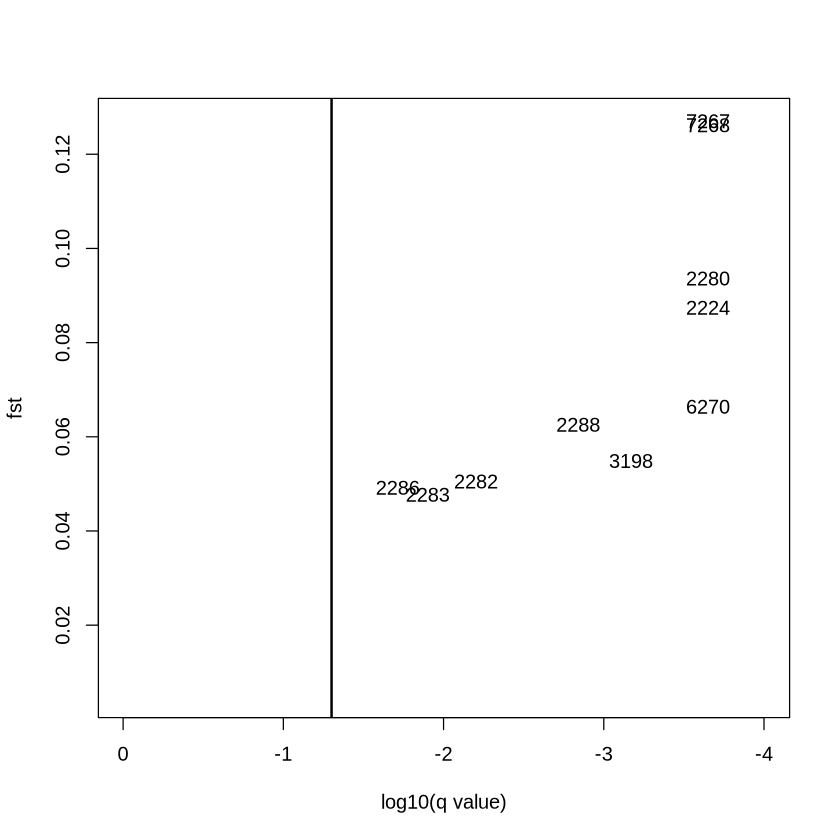

In [ ]:
plt <- plot_bayescan(infile, 0, FDR = 0.05)
out_ <- yft_bscan_fst[yft_bscan_fst$qval <= 0.05, ]

bayescan_idx <- plt$outliers

locinames <- readLines(genfile, (dim(yft_bscan_fst)[1] + 1))
locinames <- locinames[2:length(locinames)]

bayescan_out <- locinames[bayescan_idx]
write.table(
  bayescan_out,
  "bayescan_outliers.txt",
  sep = ",",
  row.names = FALSE,
  col.names = FALSE,
  quote = FALSE
)


In [16]:
print(length(bayescan_out))

[1] 13
